# EDA - Housing Dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setup 

In [26]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)
 
print("Import xong")

Import xong


# Load Data - analyze Data

In [27]:
df = pd.read_csv("../data/raw/Housing.csv")

print("Shape:", df.shape)

display(df.head());

print( "type:", df.dtypes , "\n")

print("Thống kê mô tả:", df.describe().T.round(2))

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


type: price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object 

Thống kê mô tả:            count        mean         std        min        25%        50%  \
price      545.0  4766729.25  1870439.62  1750000.0  3430000.0  4340000.0   
area       545.0     5150.54     2170.14     1650.0     3600.0     4600.0   
bedrooms   545.0        2.97        0.74        1.0        2.0        3.0   
bathrooms  545.0        1.29        0.50        1.0        1.0        1.0   
stories    545.0        1.81        0.87        1.0        1.0        2.0   
parking    545.0        0.69        0.86        0.0        0.0        0.0   

                 75%         max  
price      5740000.0  13300000.0  
area          

# Kiểm tra missing values & duplicates

In [28]:
print("Missing Values")
missing = df.isnull().sum()  # Tính tổng số missing values cho mỗi cột
print(missing[missing > 0] if missing.sum() > 0 else "Không có missing values")

print("\nDuplicate Rows")
dupes = df.duplicated().sum()
print(f"{dupes} dòng trùng lặp" if dupes > 0 else "Không có duplicate")

print("\nValue Counts - Categorical")
cat_cols = df.select_dtypes(include="object").columns

print(f"Có {len(cat_cols)} cột categorical: {list(cat_cols)}")

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Missing Values
Không có missing values

Duplicate Rows
Không có duplicate

Value Counts - Categorical
Có 7 cột categorical: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

mainroad:
mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom:
guestroom
no     448
yes     97
Name: count, dtype: int64

basement:
basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating:
hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning:
airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea:
prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\2986577588.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


# Phân phối của TARGET (price) 

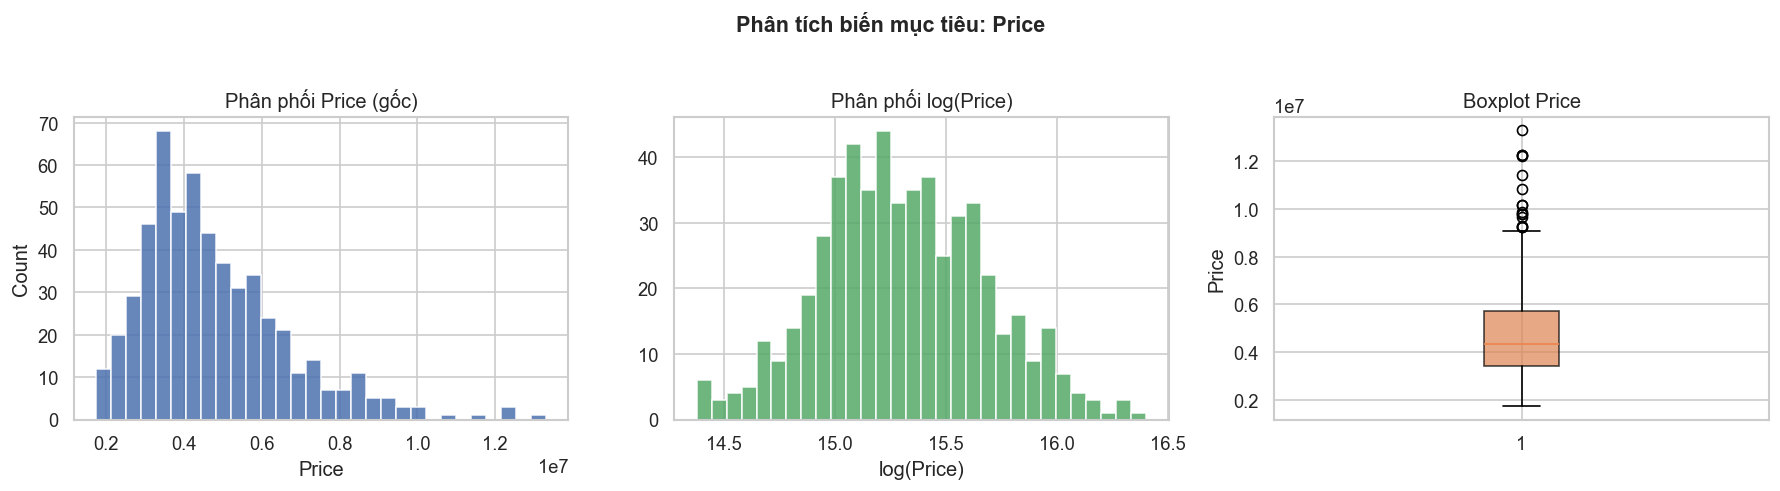


Skewness của price: 1.212
→ Lệch phải (right-skewed)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # Tạo 3 subplots trên cùng 1 hàng size: (15, 4) inch

# 4a. Histogram gốc
axes[0].hist(df["price"], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)  # 30 cột (bins=30) với màu sắc và độ trong suốt
axes[0].set_title("Phân phối Price (gốc)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

# 4b. Log-transform
log_price = np.log1p(df["price"])
axes[1].hist(log_price, bins=30, color="#55A868", edgecolor="white", alpha=0.85)  # 30 cột (bins=30) với màu sắc và độ trong suốt
axes[1].set_title("Phân phối log(Price)")
axes[1].set_xlabel("log(Price)")
 
# 4c. Boxplot
axes[2].boxplot(df["price"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#DD8452", alpha=0.7)) # Boxplot với màu sắc và độ trong suốt
axes[2].set_title("Boxplot Price")
axes[2].set_ylabel("Price")
 
plt.suptitle("Phân tích biến mục tiêu: Price", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../output/plots/01_price_distribution.png", bbox_inches="tight")
plt.show()
 
# Skewness
skew = df["price"].skew() # Tính skewness của cột price
print(f"\nSkewness của price: {skew:.3f}")
print("→ Lệch phải (right-skewed)" if skew > 0.5 else "→ Phân phối khá cân xứng") # Đánh giá mức độ lệch dựa trên giá trị skewness

# Nếu skew > 0.5: Biểu đồ lệch phải (đuôi biểu đồ kéo dài về bên phải, tức là đa số nhà giá trung bình/thấp, nhưng có một số ít căn giá rất cao).

# Phân phối các features số

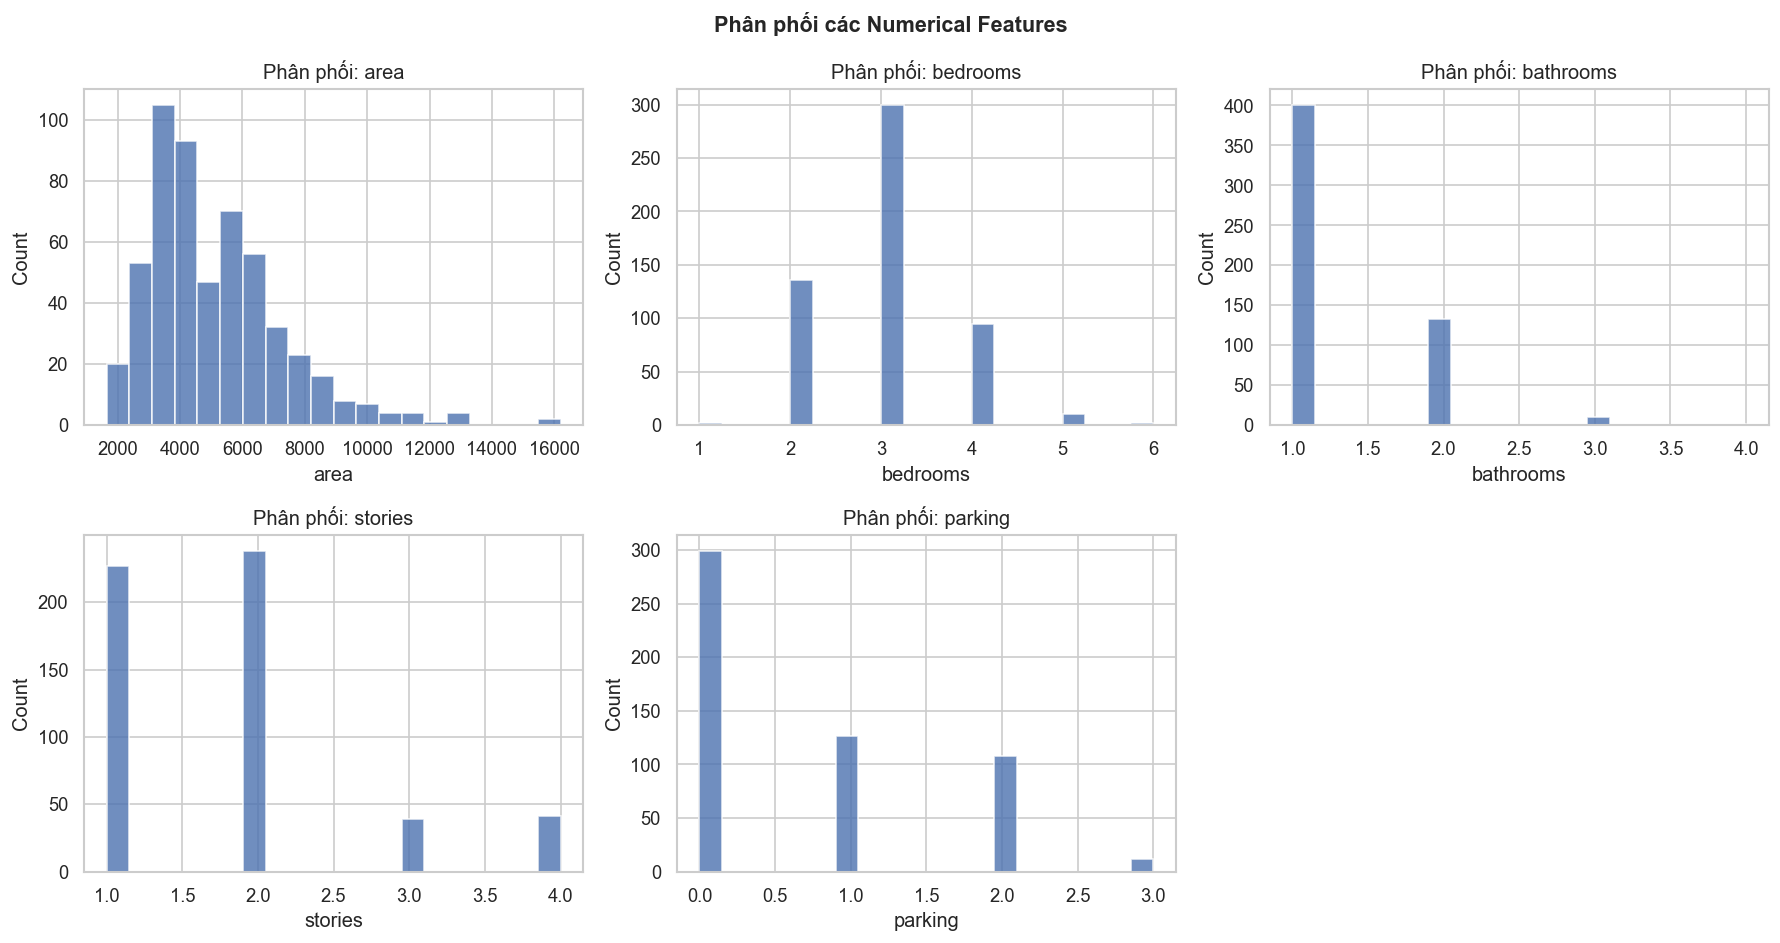

In [30]:
num_cols = ["area", "bedrooms", "bathrooms", "stories", "parking"]
 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):   # enumerate(num_cols): Trả về cả chỉ số i (0, 1, 2, 3, 4) và tên cột col tương ứng tại mỗi vòng lặp.
    axes[i].hist(df[col], bins=20, color="#4C72B0", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Phân phối: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
 
# Xóa subplot thừa
axes[-1].set_visible(False)
 
plt.suptitle("Phân phối các Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/plots/02_numerical_distributions.png", bbox_inches="tight")
plt.show()

# Scatter plot - Area vs Price

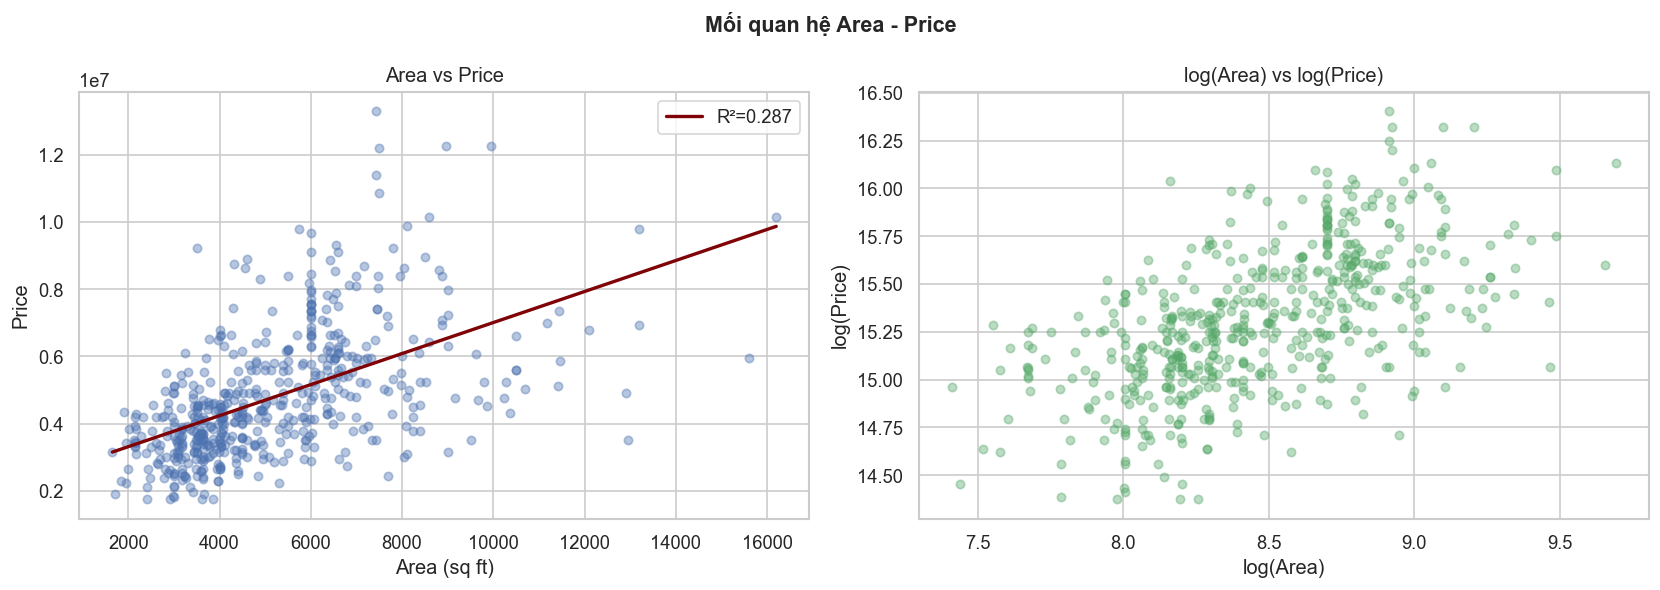

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Scatter gốc (scatter plot: biểu đồ phân tán)
axes[0].scatter(df["area"], df["price"], alpha=0.4, color="#4C72B0", s=25)
axes[0].set_title("Area vs Price")
axes[0].set_xlabel("Area (sq ft)")
axes[0].set_ylabel("Price")

# Thêm regression line
m, b, r, p, se = stats.linregress(df["area"], df["price"]) # Tính hệ số góc (m), hệ số chặn (b), hệ số tương quan (r), giá trị p (p), và sai số chuẩn (se) cho đường hồi quy tuyến tính giữa area và price
x_line = np.linspace(df["area"].min(), df["area"].max(), 100)
axes[0].plot(x_line, m * x_line + b, color="#7E0206", linewidth=2, label=f"R²={r**2:.3f}")
axes[0].legend()

# Log-log scale để thấy rõ hơn -- y = ln(x + 1) --> log1p để tránh log(0)=vô cực khi area = 0
axes[1].scatter(np.log1p(df["area"]), np.log1p(df["price"]), alpha=0.4, color="#55A868", s=25) # Vẽ scatter plot với trục log-log (log(Area) vs log(Price)) với màu sắc và độ trong suốt
axes[1].set_title("log(Area) vs log(Price)")
axes[1].set_xlabel("log(Area)")
axes[1].set_ylabel("log(Price)")
 
plt.suptitle("Mối quan hệ Area - Price", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/plots/03_area_vs_price.png", bbox_inches="tight")
plt.show()

# Correlation heatmap - Bản đồ nhiệt tương quan

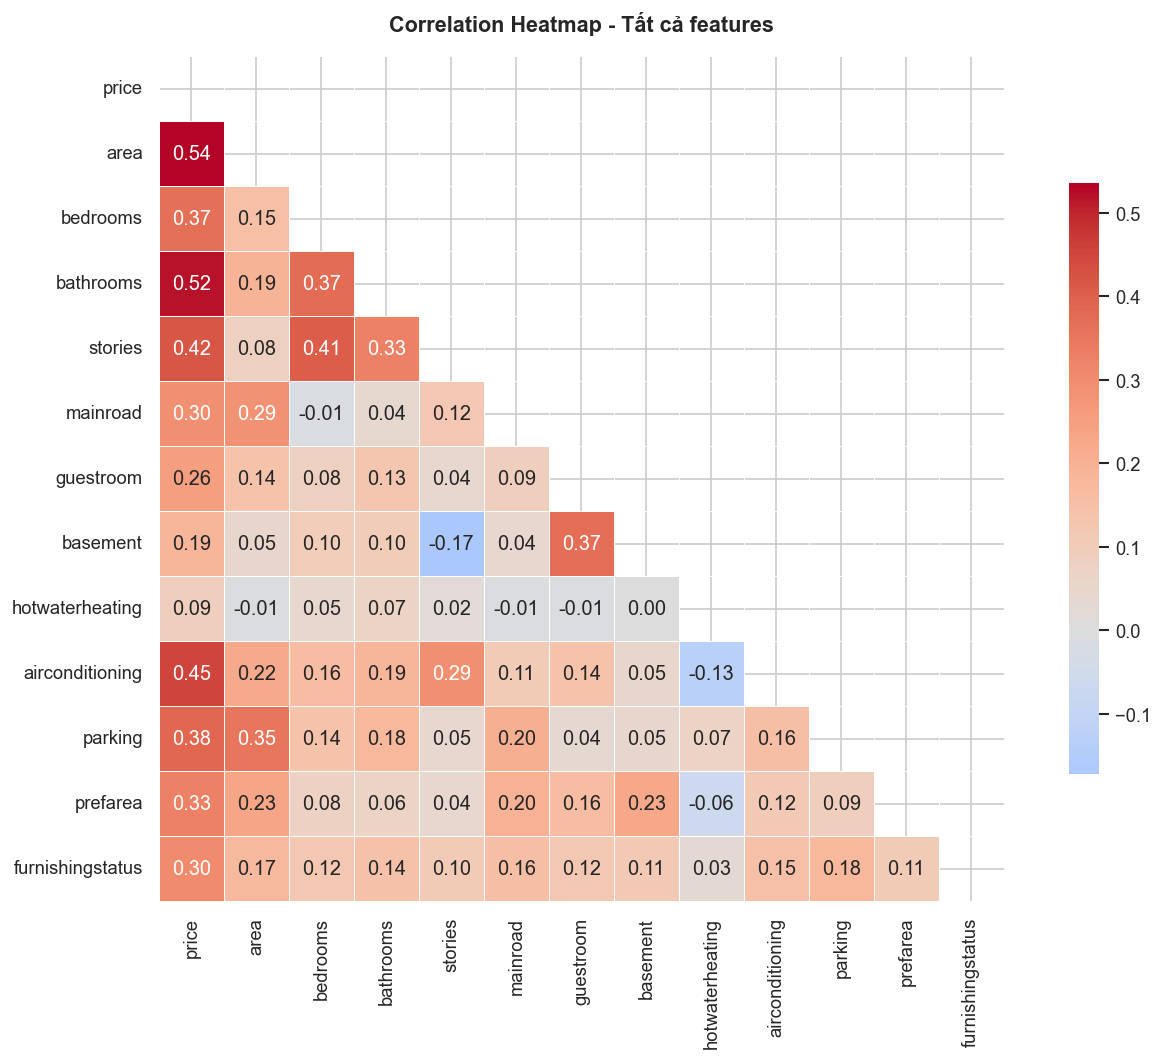


=== Tương quan với Price (|r| cao → ảnh hưởng nhiều) ===
  area                 ██████████ 0.536
  bathrooms            ██████████ 0.518
  airconditioning      █████████ 0.453
  stories              ████████ 0.421
  parking              ███████ 0.384
  bedrooms             ███████ 0.366
  prefarea             ██████ 0.330
  furnishingstatus     ██████ 0.305
  mainroad             █████ 0.297
  guestroom            █████ 0.256
  basement             ███ 0.187
  hotwaterheating      █ 0.093


In [ ]:
# Encode yes/no → 0/1 để tính correlation
df_encoded = df.copy()
binary_cols = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea"]
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({"yes": 1, "no": 0})
 
# Furnishingstatus: label encode
furnish_map = {"furnished": 2, "semi-furnished": 1, "unfurnished": 0}
df_encoded["furnishingstatus"] = df_encoded["furnishingstatus"].map(furnish_map)
 
corr = df_encoded.corr()
 
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Chỉ hiện nửa dưới
 
#Tính toán và Trực quan hóa ma trận tương quan (Heatmap) 
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    ax=ax
)
ax.set_title("Correlation Heatmap - Tất cả features", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("../output/plots/04_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# In correlation với price (xếp theo độ lớn) 
print("\nTương quan với Price (|r| cao → ảnh hưởng nhiều)")
price_corr = corr["price"].drop("price").abs().sort_values(ascending=False)
for feat, val in price_corr.items():
    bar = "█" * int(val * 20)
    print(f"  {feat:<20} {bar} {val:.3f}")

#  Boxplot - Categorical vs Price

C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],
C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],
C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],
C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:7: FutureWarning: 

Passing

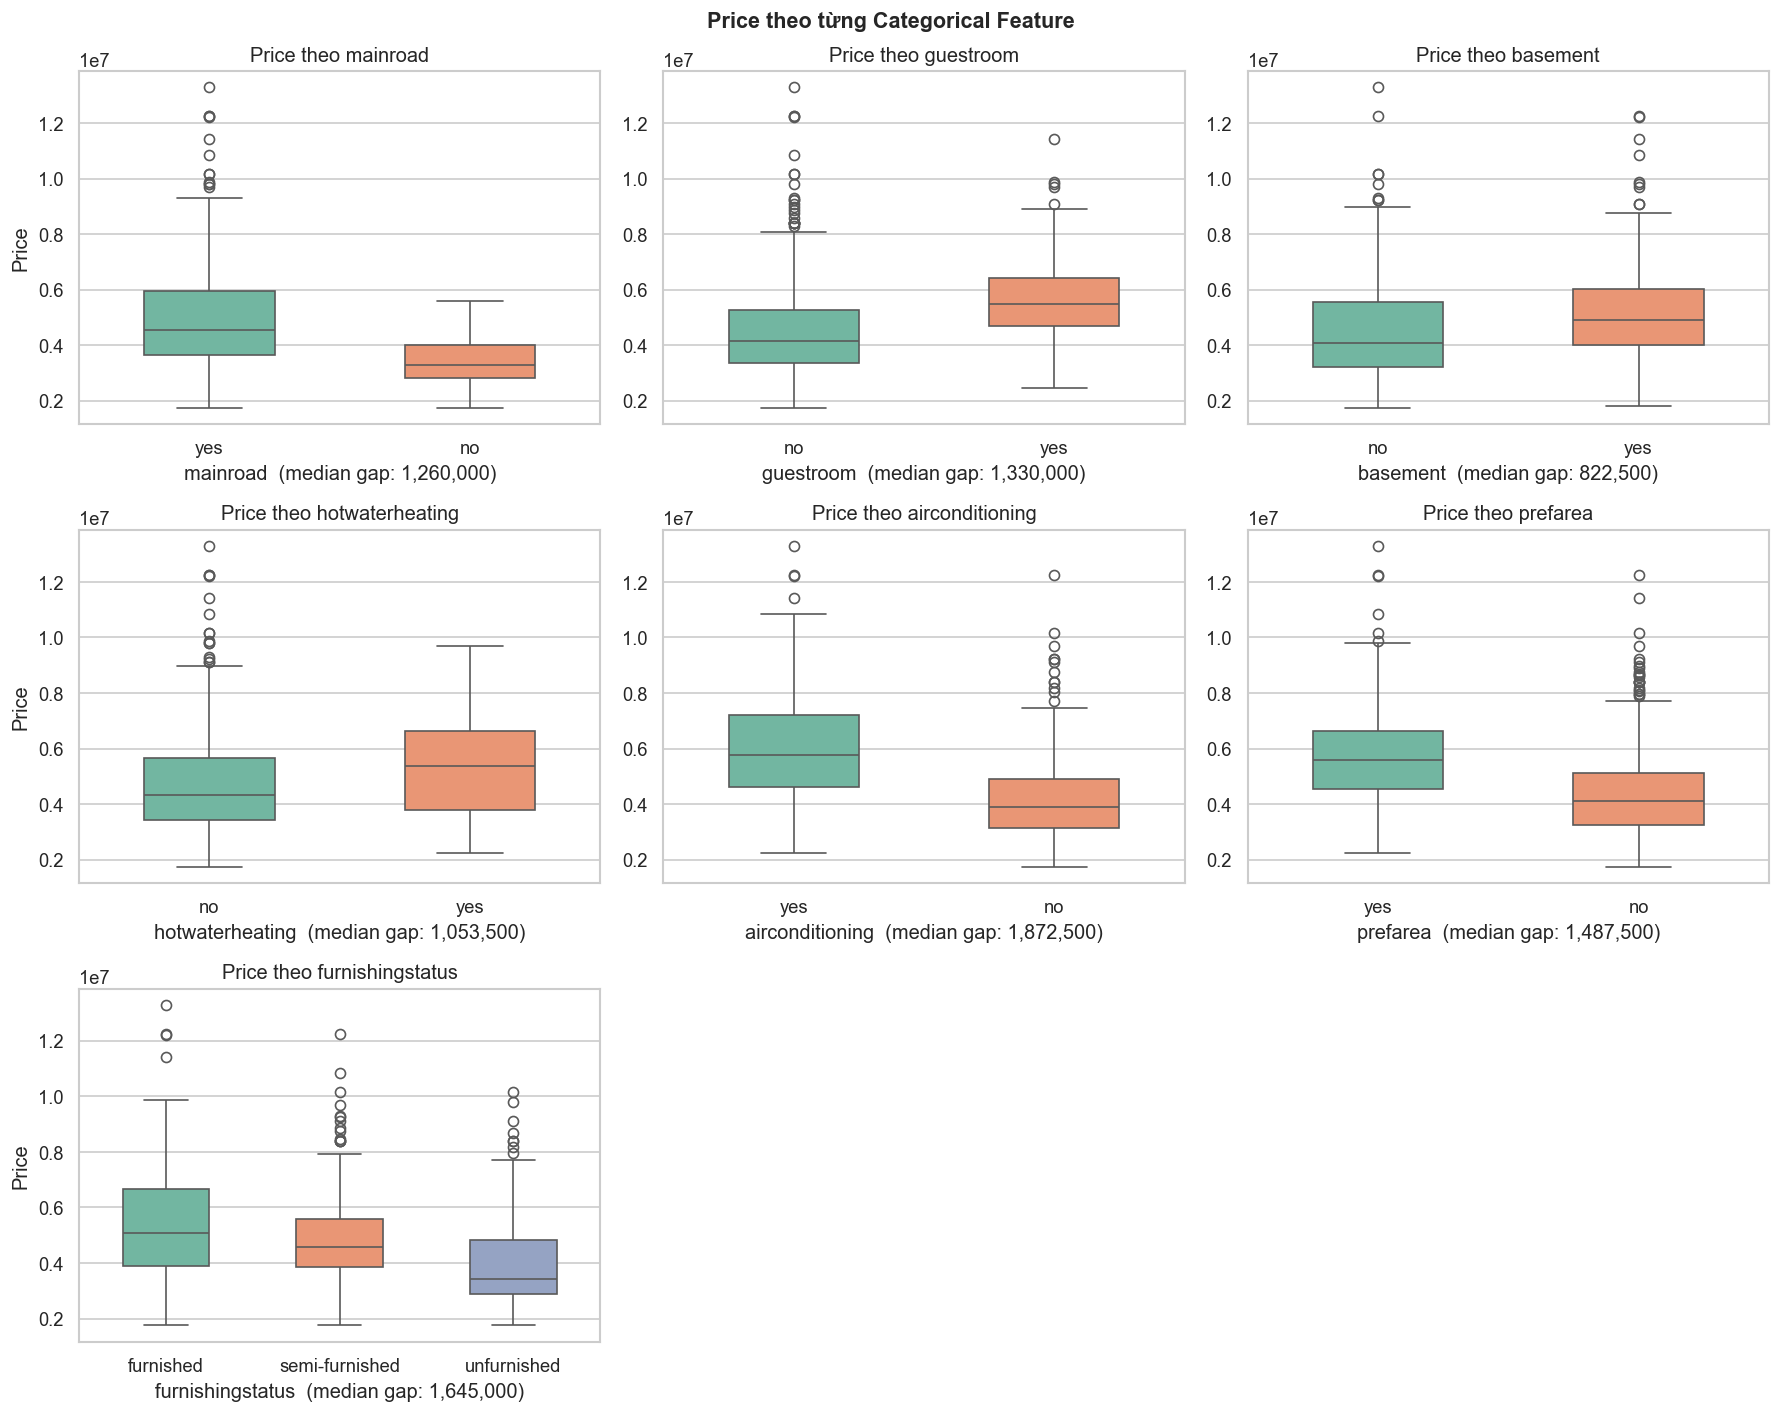

C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],
C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],
C:\Users\Admin\AppData\Local\Temp\ipykernel_16344\1407190385.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="price", ax=axes[i],


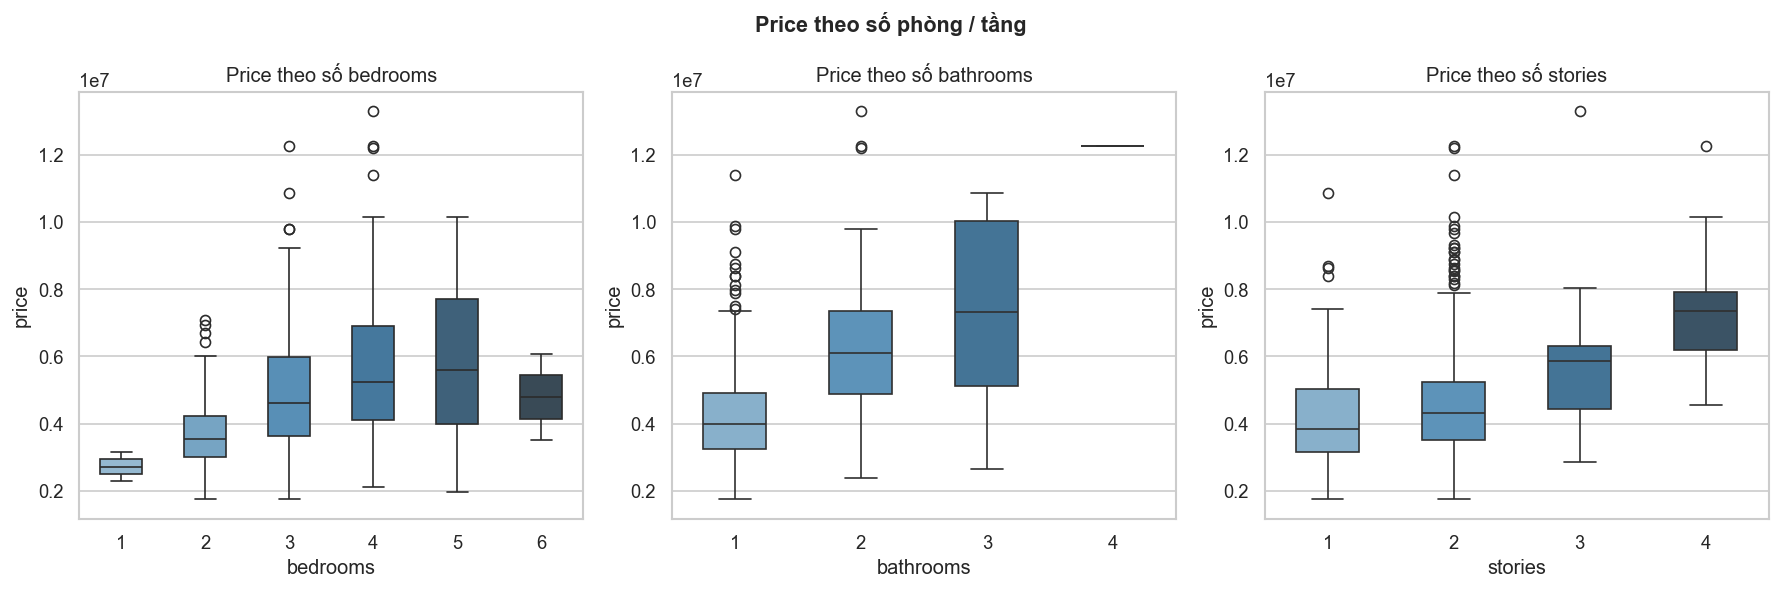

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
 
cat_binary = binary_cols + ["furnishingstatus"]
 
for i, col in enumerate(cat_binary):
    sns.boxplot(data=df, x=col, y="price", ax=axes[i],
                palette="Set2", width=0.5)
    axes[i].set_title(f"Price theo {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Price" if i % 3 == 0 else "")
 
    # Tính median difference
    groups = df.groupby(col)["price"].median()
    axes[i].set_xlabel(f"{col}  (median gap: {groups.max()-groups.min():,.0f})")
 
# Ẩn subplots thừa
for j in range(len(cat_binary), len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Price theo từng Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/plots/05_categorical_vs_price.png", bbox_inches="tight")
plt.show()
 
 
# ── CELL 9: Boxplot - Discrete numeric vs Price ──────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
discrete_cols = ["bedrooms", "bathrooms", "stories"]
 
for i, col in enumerate(discrete_cols):
    sns.boxplot(data=df, x=col, y="price", ax=axes[i],
                palette="Blues_d", width=0.5)
    axes[i].set_title(f"Price theo số {col}")
 
plt.suptitle("Price theo số phòng / tầng", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/plots/06_rooms_vs_price.png", bbox_inches="tight")
plt.show()

# Phát hiện Outliers (IQR method)

=== Outliers theo IQR method ===

price:
  Q1=3,430,000  Q3=5,740,000  IQR=2,310,000
  Lower fence: -35,000
  Upper fence: 9,205,000
  Outliers: 15 (2.8%)

area:
  Q1=3,600  Q3=6,360  IQR=2,760
  Lower fence: -540
  Upper fence: 10,500
  Outliers: 12 (2.2%)



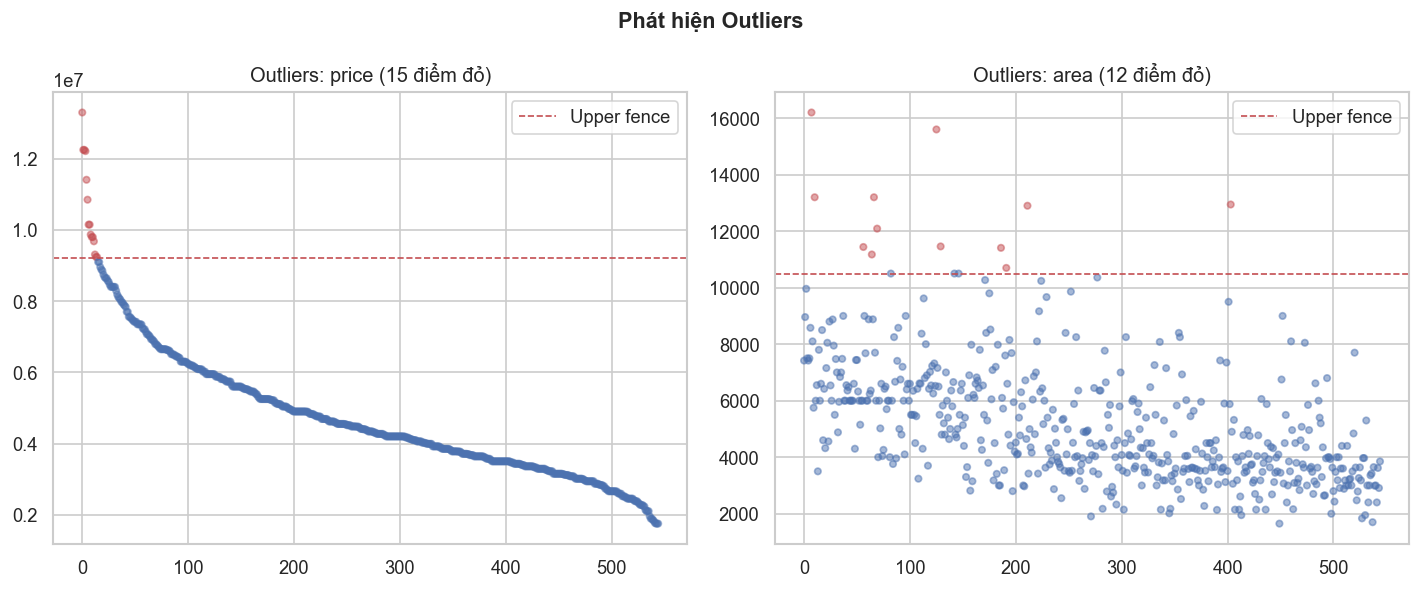

In [36]:
print("=== Outliers theo IQR method ===\n")
outlier_report = {}
 
for col in ["price", "area"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    outlier_report[col] = n_out
    print(f"{col}:")
    print(f"  Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}")
    print(f"  Lower fence: {lower:,.0f}")
    print(f"  Upper fence: {upper:,.0f}")
    print(f"  Outliers: {n_out} ({pct:.1f}%)\n")
 
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(["price", "area"]):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    colors = ["#C44E52" if v > upper else "#4C72B0" for v in df[col]]
    axes[i].scatter(range(len(df)), df[col], c=colors, alpha=0.5, s=15)
    axes[i].axhline(upper, color="#C44E52", linestyle="--", linewidth=1, label="Upper fence")
    axes[i].set_title(f"Outliers: {col} ({outlier_report[col]} điểm đỏ)")
    axes[i].legend()
 
plt.suptitle("Phát hiện Outliers", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../output/plots/07_outliers.png", bbox_inches="tight")
plt.show()

# Summary report

In [38]:
print("=" * 55)
print("       📊 KẾT LUẬN EDA - HOUSING DATASET")
print("=" * 55)
print(f"\n📁 Dataset: {df.shape[0]} mẫu, {df.shape[1]} features")
print(f"🎯 Target: price  |  Skewness: {df['price'].skew():.2f} (nên log-transform)")
print(f"❓ Missing values: {df.isnull().sum().sum()} (không có)")
 
top_feats = price_corr.head(4).index.tolist()
print(f"\n🔑 Features quan trọng nhất (tương quan với price):")
for f in top_feats:
    print(f"   • {f}: {corr.loc[f, 'price']:.3f}")
 
print(f"\n⚠️  Outliers: price ({outlier_report['price']}), area ({outlier_report['area']})")
print(f"\n✅ Bước tiếp theo → Preprocessing:")
print("   1. Encode binary cols (yes/no → 0/1)")
print("   2. One-Hot Encode furnishingstatus")
print("   3. Log-transform price nếu skew > 0.5")
print("   4. StandardScaler cho area")
print("   5. Train/test split 80/20")
print("=" * 55)

       📊 KẾT LUẬN EDA - HOUSING DATASET

📁 Dataset: 545 mẫu, 13 features
🎯 Target: price  |  Skewness: 1.21 (nên log-transform)
❓ Missing values: 0 (không có)

🔑 Features quan trọng nhất (tương quan với price):
   • area: 0.536
   • bathrooms: 0.518
   • airconditioning: 0.453
   • stories: 0.421

⚠️  Outliers: price (15), area (12)

✅ Bước tiếp theo → Preprocessing:
   1. Encode binary cols (yes/no → 0/1)
   2. One-Hot Encode furnishingstatus
   3. Log-transform price nếu skew > 0.5
   4. StandardScaler cho area
   5. Train/test split 80/20
